# PandaX-4T reconstruction maps: digitized CSV -> appletree JSON

Builds the appletree map JSONs consumed by the PandaX-4T chain from the digitized PRD Fig. 6 / Fig. 12 CSVs, and verifies them by (A) re-applying each map through appletree's interpolator and overlaying on the digitized points, and (B) running the full chain and checking the maps take effect.

**Conventions (per design):**
- **Hit-clustering** (`pandax4t_hit_eff`): a single shared `Map` (no SigmaMap). The CSV is the *survival* probability $1-\epsilon_{hit}$ vs $N_{det}$ (Fig. 6 y-axis), used directly as `B(N_det, hit_eff)`.
- **Cut acceptance** (`s1_cut_acc`, `s2_cut_acc`): run-split `SigmaMap`; the lower/upper bands are set equal to the median (no acceptance band assumed).
- **S1/S2 bias** (`s1_bias`/`s1_smear`, `s2_bias`/`s2_smear`): shared across runs. appletree draws `area = N_pe*(1+bias)`, `bias ~ Normal(bias_map, smear_map)`. The digitized curve is the reconstruction factor (median ~0.97), so `bias_map = median - 1` and `smear_map = (upper - lower)/2`.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import diamx
import appletree as apt
from appletree.config import Map, SigmaMap

MAPS = os.path.join(os.path.dirname(diamx.__file__), 'appletree', 'maps')
load_csv = lambda n: np.loadtxt(os.path.join(MAPS, n), delimiter=',')

def write_point_map(name, x, y, coord_name):
    x = np.asarray(x, float); y = np.asarray(y, float)
    order = np.argsort(x); x, y = x[order], y[order]
    json.dump({'coordinate_system': x.tolist(), 'coordinate_type': 'point',
               'coordinate_name': coord_name, 'map': y.tolist()},
              open(os.path.join(MAPS, name), 'w'))
    print(f'wrote {name:42s} ({len(x):3d} pts  x[{x.min():.3g},{x.max():.3g}]  y[{y.min():.3g},{y.max():.3g}])')
    return x, y

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


/home/mhliu/Documents/appletree/appletree/__init__.py:54: UserWarning: You are running appletree on CPU, which usually results in low performance.
  warn(warning)


## 1. Hit-clustering survival (shared, single Map)

In [2]:
hit = load_csv('pandax4t_hit_eff.csv')   # x = N_det, y = 1 - eps_hit (survival)
hx, hy = write_point_map('pandax4t_hit_eff.json', hit[:, 0], np.clip(hit[:, 1], 0, 1), 'num_s1_phd')

wrote pandax4t_hit_eff.json                      (208 pts  x[2,94.8]  y[0.9,1])


## 2. Cut acceptance (run-split SigmaMap; lower/upper = median)

In [3]:
cut = {}
for run in ['run0', 'run1']:
    for which in ['s1', 's2']:
        med = load_csv(f'pandax4t_{run}_{which}_cut_acc_median.csv')
        x, y = med[:, 0], np.clip(med[:, 1], 0, 1)
        coord = f'{which}_area'
        for tag in ['median', 'lower', 'upper']:   # band == median (assumed)
            write_point_map(f'pandax4t_{run}_{which}_cut_acc_{tag}.json', x, y, coord)
        cut[(run, which)] = (x, y)

wrote pandax4t_run0_s1_cut_acc_median.json       ( 28 pts  x[2.63,147]  y[0.847,1])
wrote pandax4t_run0_s1_cut_acc_lower.json        ( 28 pts  x[2.63,147]  y[0.847,1])
wrote pandax4t_run0_s1_cut_acc_upper.json        ( 28 pts  x[2.63,147]  y[0.847,1])
wrote pandax4t_run0_s2_cut_acc_median.json       ( 15 pts  x[49.3,1.45e+03]  y[0.902,1])
wrote pandax4t_run0_s2_cut_acc_lower.json        ( 15 pts  x[49.3,1.45e+03]  y[0.902,1])
wrote pandax4t_run0_s2_cut_acc_upper.json        ( 15 pts  x[49.3,1.45e+03]  y[0.902,1])
wrote pandax4t_run1_s1_cut_acc_median.json       ( 28 pts  x[2.63,147]  y[0.819,1])
wrote pandax4t_run1_s1_cut_acc_lower.json        ( 28 pts  x[2.63,147]  y[0.819,1])
wrote pandax4t_run1_s1_cut_acc_upper.json        ( 28 pts  x[2.63,147]  y[0.819,1])
wrote pandax4t_run1_s2_cut_acc_median.json       ( 15 pts  x[49.3,1.45e+03]  y[0.912,1])
wrote pandax4t_run1_s2_cut_acc_lower.json        ( 15 pts  x[49.3,1.45e+03]  y[0.912,1])
wrote pandax4t_run1_s2_cut_acc_upper.json        ( 

## 3. S1/S2 reconstruction bias + smearing (shared)

In [4]:
bias = {}
for which, coord in [('s1', 'num_s1_pe'), ('s2', 'num_s2_pe')]:
    med = load_csv(f'pandax4t_{which}_bias_median.csv')
    lo  = load_csv(f'pandax4t_{which}_bias_lower.csv')
    up  = load_csv(f'pandax4t_{which}_bias_upper.csv')
    x = np.sort(med[:, 0])
    med_i = np.interp(x, med[:, 0], med[:, 1])
    lo_i  = np.interp(x, lo[:, 0],  lo[:, 1])
    up_i  = np.interp(x, up[:, 0],  up[:, 1])
    # appletree: area = N_pe*(1+bias), bias ~ Normal(bias_map, smear_map)
    write_point_map(f'pandax4t_{which}_bias.json',  x, med_i - 1.0, coord)
    write_point_map(f'pandax4t_{which}_smear.json', x, np.clip((up_i - lo_i) / 2.0, 1e-4, None), coord)
    bias[which] = dict(x=x, med=med_i, lo=lo_i, up=up_i)

wrote pandax4t_s1_bias.json                      ( 99 pts  x[2.06,96.3]  y[-0.033,-0.0234])
wrote pandax4t_s1_smear.json                     ( 99 pts  x[2.06,96.3]  y[0.00638,0.0521])
wrote pandax4t_s2_bias.json                      ( 84 pts  x[28.1,2.97e+03]  y[-0.0384,0.0152])
wrote pandax4t_s2_smear.json                     ( 84 pts  x[28.1,2.97e+03]  y[0.0135,0.0985])


## 4. Electron lifetime (run-split quantile map)
appletree's `DriftLoss` samples `elife = map(U(0,1))`, so the map is the **inverse-CDF
(quantile function)** of the electron-lifetime distribution over the science-run exposure
— *not* elife-vs-time. It is built from the per-period digitized curves
`pandax4t_run{run}_elife_{i}.csv` (col0 = month, 1 = 2020-01; col1 = elife [µs], one file
per continuous science period between calibrations), livetime-weighted by resampling each
period on a uniform time grid (assumes ~uniform live fraction within/across periods).

To **use** the maps in the chain, also set per-run `drift_velocity` ≈ 0.145 cm/µs and the z
geometry (max \|z\| ≈ 120 cm → max drift ~828 µs), and point the instruct `elife` at
`pandax4t_run{run}_elife.json`. Run1 curves are picked up automatically once digitized.

wrote pandax4t_run0_elife.json                   ( 41 pts  x[0,1]  y[405,1.34e+03])
  run0: 8 periods, calendar livetime 3.88 months (0.3234 yr); elife median 1148 us, range [405,1344] us
wrote pandax4t_run1_elife.json                   ( 41 pts  x[0,1]  y[504,1.76e+03])
  run1: 2 periods, calendar livetime 5.68 months (0.4732 yr); elife median 1550 us, range [504,1760] us


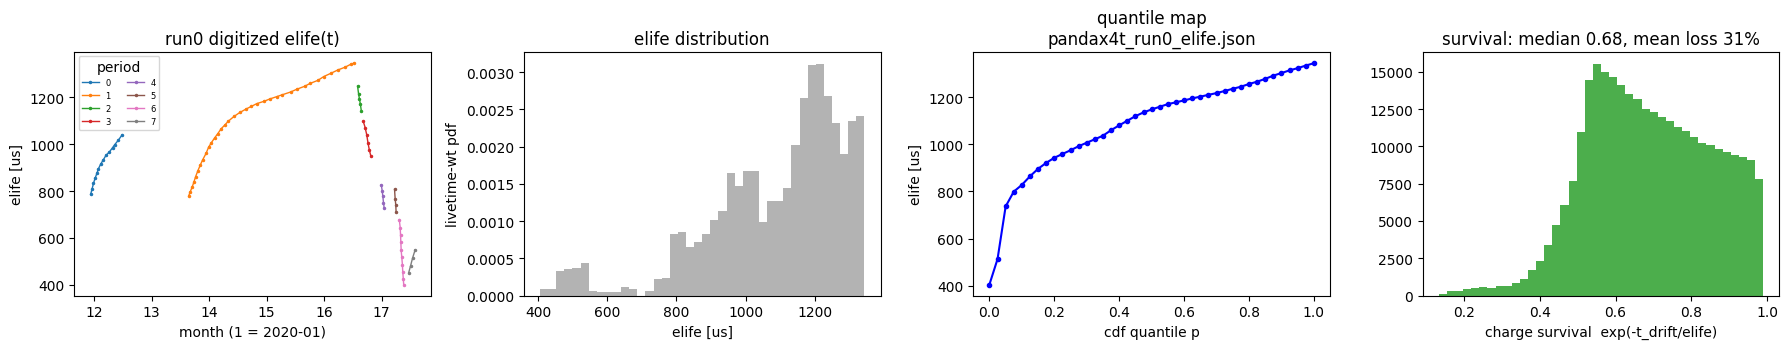

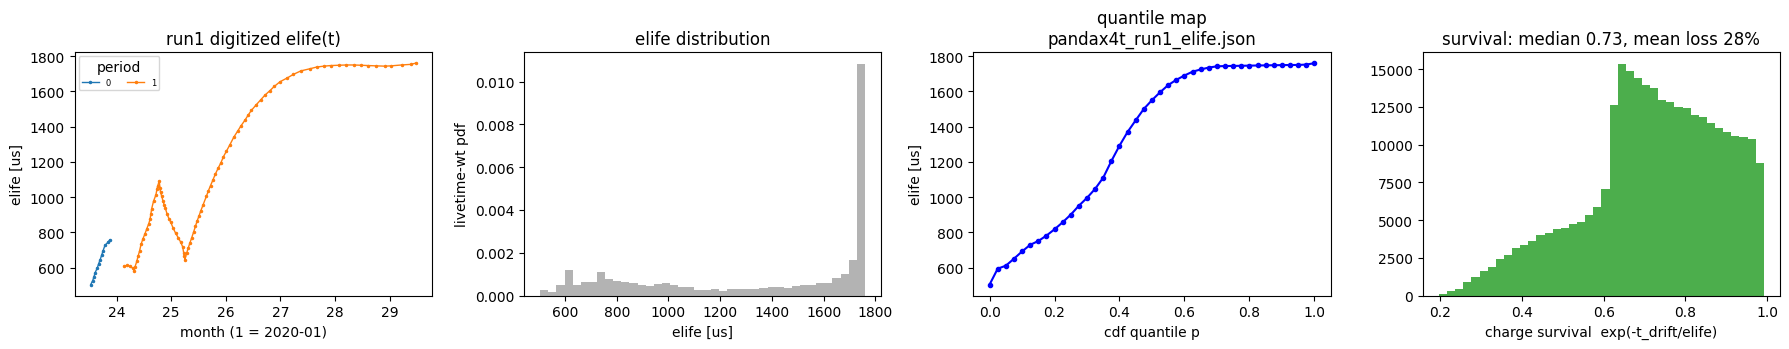

In [2]:
# Electron-lifetime quantile maps from the per-period digitized elife(t) curves.
import glob
DATA = os.path.join(os.path.dirname(diamx.__file__), 'data')
DRIFT_V, MAX_Z = 0.145, 120.0   # cm/us, cm  -> max drift ~828 us

def build_elife_map(run, n_quantiles=41, dt=0.002):
    """Inverse-CDF (quantile) map of elife over the livetime-weighted science exposure."""
    files = sorted(glob.glob(os.path.join(DATA, f'pandax4t_run{run}_elife_*.csv')),
                   key=lambda f: int(os.path.basename(f).split('_')[-1].split('.')[0]))
    if not files:
        print(f'run{run}: no digitized elife files yet'); return None
    samples, periods = [], []
    for f in files:
        d = np.loadtxt(f, delimiter=','); t, e = d[:, 0], d[:, 1]
        o = np.argsort(t); t, e = t[o], e[o]
        grid = np.arange(t[0], t[-1], dt) if t[-1] - t[0] > dt else t   # uniform time = livetime weight
        samples.append(np.interp(grid, t, e)); periods.append((t, e))
    elife = np.concatenate(samples)
    p = np.linspace(0, 1, n_quantiles); q = np.percentile(elife, 100 * p)
    write_point_map(f'pandax4t_run{run}_elife.json', p, q, 'cdf')
    lt = sum(t[-1] - t[0] for t, _ in periods)
    print(f'  run{run}: {len(files)} periods, calendar livetime {lt:.2f} months ({lt/12:.4f} yr); '
          f'elife median {np.median(elife):.0f} us, range [{elife.min():.0f},{elife.max():.0f}] us')
    return p, q, elife, periods

elife_results = {}
for run in (0, 1):
    r = build_elife_map(run)
    if r is not None:
        elife_results[run] = r

# --- validation: digitized curves, distribution, quantile map, resulting charge survival ---
for run, (p, q, elife, periods) in elife_results.items():
    fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
    for i, (t, e) in enumerate(periods):
        ax[0].plot(t, e, '.-', ms=3, lw=1, label=f'{i}')
    ax[0].set_xlabel('month (1 = 2020-01)'); ax[0].set_ylabel('elife [us]')
    ax[0].set_title(f'run{run} digitized elife(t)'); ax[0].legend(fontsize=6, ncol=2, title='period')
    ax[1].hist(elife, bins=40, density=True, color='0.7')
    ax[1].set_xlabel('elife [us]'); ax[1].set_ylabel('livetime-wt pdf'); ax[1].set_title('elife distribution')
    ax[2].plot(p, q, 'b.-'); ax[2].set_xlabel('cdf quantile p'); ax[2].set_ylabel('elife [us]')
    ax[2].set_title(f'quantile map\npandax4t_run{run}_elife.json')
    rng = np.random.default_rng(0)
    zt = rng.uniform(2, MAX_Z, 300000); ev = np.interp(rng.uniform(0, 1, 300000), p, q)
    surv = np.exp(-(zt / DRIFT_V) / ev)
    ax[3].hist(surv, bins=40, color='tab:green', alpha=0.85)
    ax[3].set_xlabel('charge survival  exp(-t_drift/elife)')
    ax[3].set_title(f'survival: median {np.median(surv):.2f}, mean loss {100*(1-surv.mean()):.0f}%')
    fig.tight_layout(); plt.show()


## A. Verify: re-apply each map through appletree's interpolator
Each generated map is loaded back via appletree's `Map`/`SigmaMap` and applied over the digitized abscissa; the curve must overlay the digitized points.

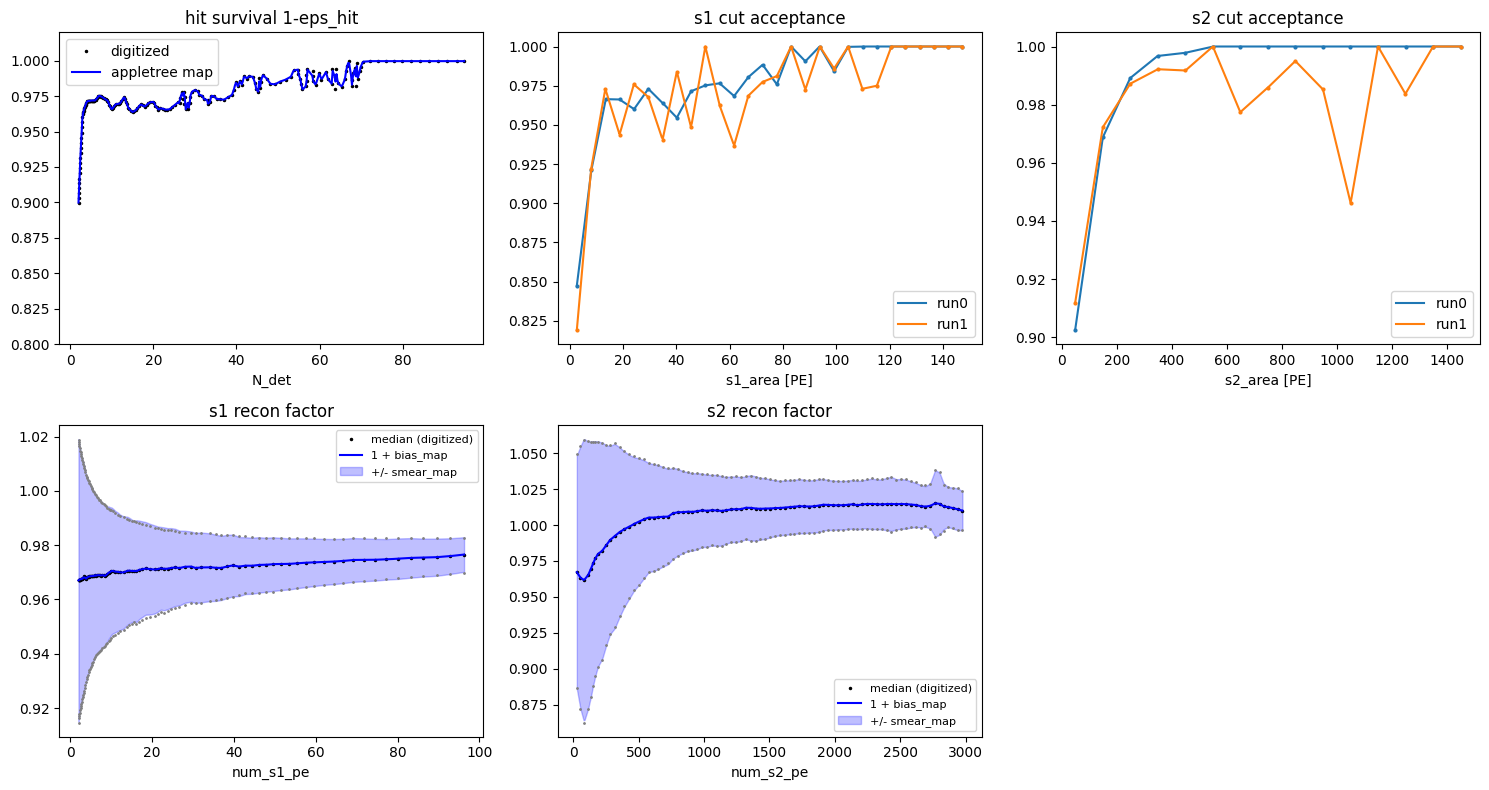

In [5]:
def apply_map(jsonname, x, method='LERP'):
    # unique Map name per file -- appletree caches built maps by name
    nm = 'chk_' + jsonname.replace('.json', '').replace('-', '_')
    m = Map(name=nm, method=method, default=os.path.join(MAPS, jsonname)); m.build()
    return np.asarray(m.apply(np.asarray(x, float)))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
# hit eff
xs = np.linspace(hx.min(), hx.max(), 400)
ax[0,0].plot(hit[:,0], hit[:,1], 'k.', ms=3, label='digitized')
ax[0,0].plot(xs, apply_map('pandax4t_hit_eff.json', xs), 'b-', label='appletree map')
ax[0,0].set(title='hit survival 1-eps_hit', xlabel='N_det', ylim=(0.8,1.02)); ax[0,0].legend()
# cut acc
for j, which in enumerate(['s1','s2']):
    for run, c in [('run0','tab:blue'), ('run1','tab:orange')]:
        x, y = cut[(run, which)]
        xs = np.linspace(x.min(), x.max(), 400)
        ax[0,j+1].plot(x, y, '.', color=c, ms=4)
        ax[0,j+1].plot(xs, apply_map(f'pandax4t_{run}_{which}_cut_acc_median.json', xs), '-', color=c, label=run)
    ax[0,j+1].set(title=f'{which} cut acceptance', xlabel=f'{which}_area [PE]'); ax[0,j+1].legend()
# bias (1 + bias_map) vs median; smear band
for j, which in enumerate(['s1','s2']):
    b = bias[which]; xs = np.linspace(b['x'].min(), b['x'].max(), 400)
    recon = 1.0 + apply_map(f'pandax4t_{which}_bias.json', xs)
    sm = apply_map(f'pandax4t_{which}_smear.json', xs)
    ax[1,j].plot(b['x'], b['med'], 'k.', ms=3, label='median (digitized)')
    ax[1,j].plot(b['x'], b['lo'], '.', color='gray', ms=2); ax[1,j].plot(b['x'], b['up'], '.', color='gray', ms=2)
    ax[1,j].plot(xs, recon, 'b-', label='1 + bias_map')
    ax[1,j].fill_between(xs, recon - sm, recon + sm, alpha=0.25, color='b', label='+/- smear_map')
    ax[1,j].set(title=f'{which} recon factor', xlabel=f'num_{which}_pe'); ax[1,j].legend(fontsize=8)
ax[1,2].axis('off')
fig.tight_layout(); plt.show()

## B. Verify: run the full chain and confirm the maps take effect
Build `NRPandaX4T` with the Run0 instruct, deduce the reconstruction intermediates, and check: (i) `s1_area/num_s1_pe` reproduces the S1 bias map mean/sigma, (ii) the same for S2, (iii) `cut_acc_s1/s2` match the cut-acceptance maps, (iv) hit clustering lowers the S1 relative to a no-loss (survival=1) map.

In [6]:
from diamx.appletree import get_file_path_diamx
from diamx.appletree.components.pandax4t import NRPandaX4T

with open(get_file_path_diamx('pandax4t_run0_nr.json')) as f:
    instruct = json.load(f)
instruct.update({'lower_energy': 1.0, 'upper_energy': 60.0})

def subst(cfg):
    out = {}
    for k, v in cfg.items():
        if isinstance(v, list):
            nv = []
            for e in v:
                try: nv.append(get_file_path_diamx(e))
                except RuntimeError: nv.append(e)
            out[k] = nv
        elif isinstance(v, str):
            try: out[k] = get_file_path_diamx(v)
            except RuntimeError: out[k] = v
        else: out[k] = v
    return out

pm = apt.Parameter(get_file_path_diamx('pandax4t_run0_nr_par.json')); pm.sample_prior()
params = dict(pm.get_all_parameter())
params.update({'field':93.0,'g1':0.0997,'g2':4.12,'gas_gain':20.0,'drift_velocity':0.0677,
               'p_dpe':0.22,'elife_sigma':0.0,'s1_cut_acc_sigma':0.0,'s2_cut_acc_sigma':0.0})

want = ['num_s1_pe','s1_area','num_s2_pe','s2_area','cut_acc_s1','cut_acc_s2']
apt.share.clear_cache()
comp = NRPandaX4T('mapcheck', llh_name='mapcheck')
comp.deduce(data_names=want, force_no_eff=True)
default_configs = {}
for plugin_name, _, _ in comp.worksheet:
    pc = eval(f'apt.plugins.{plugin_name}')
    for cn, cf in pc.takes_config.items():
        try: default_configs[cn] = cf.get_default()
        except ValueError: pass
default_configs.update(instruct)
apt.share.clear_cache(); comp.set_config(subst(default_configs))
comp.deduce(data_names=want, force_no_eff=True); comp.compile()
key = apt.get_key()
key, (n1pe, s1a, n2pe, s2a, ca1, ca2) = comp.simulate(key, 500000, params)
n1pe,s1a,n2pe,s2a,ca1,ca2 = (np.asarray(v) for v in (n1pe,s1a,n2pe,s2a,ca1,ca2))

/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


mapcheck's map s2_cut_acc is using the parameter s2_cut_acc_sigma.
mapcheck's map s1_cut_acc is using the parameter s1_cut_acc_sigma.


cut_acc_s1: MC mean 0.9521 | map@<s1>=35.2 -> 0.9633
cut_acc_s2: MC mean 0.9872 | map@<s2>=421.4 -> 0.9975


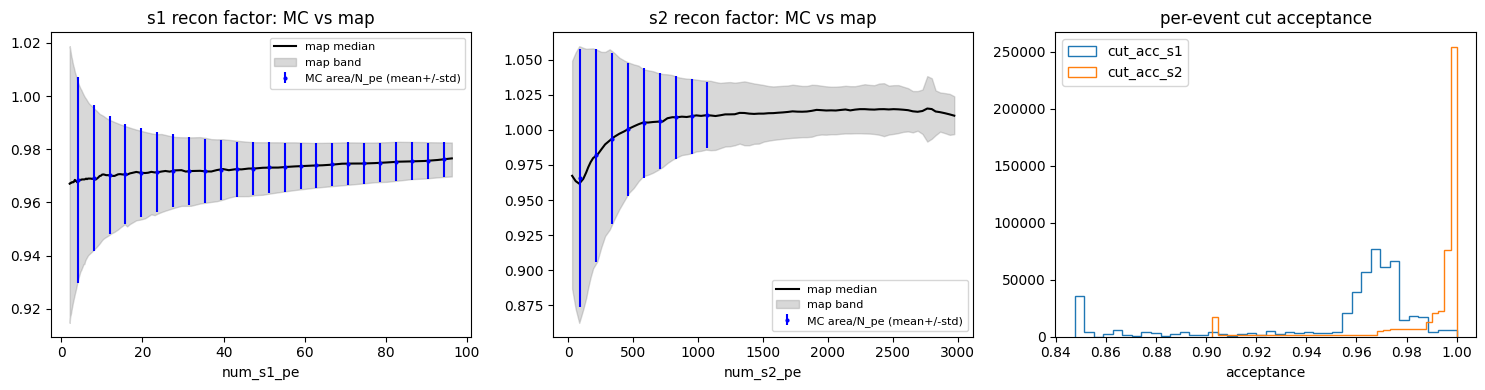

In [7]:
# (i,ii) recon factor area/N_pe vs the bias map, binned
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for j,(which,npe,area) in enumerate([('s1',n1pe,s1a),('s2',n2pe,s2a)]):
    good = npe > 0; rf = area[good]/npe[good]; xv = npe[good]
    b = bias[which]; edges = np.linspace(b['x'].min(), b['x'].max(), 25); ctr = 0.5*(edges[:-1]+edges[1:])
    idx = np.digitize(xv, edges)-1
    mean = np.array([rf[idx==k].mean() if (idx==k).sum()>50 else np.nan for k in range(len(ctr))])
    std  = np.array([rf[idx==k].std()  if (idx==k).sum()>50 else np.nan for k in range(len(ctr))])
    ax[j].plot(b['x'], b['med'], 'k-', label='map median')
    ax[j].fill_between(b['x'], b['lo'], b['up'], color='gray', alpha=0.3, label='map band')
    ax[j].errorbar(ctr, mean, yerr=std, fmt='b.', ms=4, label='MC area/N_pe (mean+/-std)')
    ax[j].set(title=f'{which} recon factor: MC vs map', xlabel=f'num_{which}_pe'); ax[j].legend(fontsize=8)
# (iii) cut acc check
print('cut_acc_s1: MC mean %.4f' % ca1.mean(), '| map@<s1>=%.1f -> %.4f' % (s1a.mean(), float(apply_map('pandax4t_run0_s1_cut_acc_median.json',[s1a.mean()])[0])))
print('cut_acc_s2: MC mean %.4f' % ca2.mean(), '| map@<s2>=%.1f -> %.4f' % (s2a.mean(), float(apply_map('pandax4t_run0_s2_cut_acc_median.json',[s2a.mean()])[0])))
ax[2].hist(ca1, bins=40, histtype='step', label='cut_acc_s1'); ax[2].hist(ca2, bins=40, histtype='step', label='cut_acc_s2')
ax[2].set(title='per-event cut acceptance', xlabel='acceptance'); ax[2].legend()
fig.tight_layout(); plt.show()

In [8]:
# (iv) hit clustering lowers S1 vs a unity-survival map
import copy
tmp = os.path.join(MAPS, '_unity_hit_eff.json')
json.dump({'coordinate_system':[0.0,300.0],'coordinate_type':'point','coordinate_name':'num_s1_phd','map':[1.0,1.0]}, open(tmp,'w'))
def run_s1(hit_map):
    cfg = subst({**default_configs, 'hit_eff': hit_map})
    tag = 'hc_' + os.path.basename(hit_map).split('.')[0]
    apt.share.clear_cache()
    c = NRPandaX4T(tag, llh_name=tag)
    c.deduce(data_names=['s1_area'], force_no_eff=True)
    apt.share.clear_cache(); c.set_config(cfg); c.deduce(data_names=['s1_area'], force_no_eff=True); c.compile()
    k = apt.get_key(); k, s1 = c.simulate(k, 500000, params); return float(np.asarray(s1).mean())
s1_real = run_s1('pandax4t_hit_eff.json'); s1_unity = run_s1('_unity_hit_eff.json')
os.remove(tmp)
print(f'mean s1_area: hit-clustering ON {s1_real:.3f}  vs survival=1 {s1_unity:.3f}  -> ratio {s1_real/s1_unity:.3f} (<1 expected)')

/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(
/home/mhliu/Documents/appletree/appletree/component.py:499: UserWarning: New config is set, please run deduce() and compile() again to update the simulation code.
  warn(


mean s1_area: hit-clustering ON 35.199  vs survival=1 35.824  -> ratio 0.983 (<1 expected)
